# Taller: exploración computacional de la regresión logística

**Introducción al Machine Learning — Universidad El Bosque — 2026-2**

Integrantes: _(completar con los nombres del grupo)_

Este cuaderno importa las funciones reutilizables definidas en `src/` y las
usa para resolver los 5 ejercicios del taller. No se redefine ninguna
función aquí; solo se llaman, se organizan los resultados y se generan las
figuras, que se guardan en `resultados/`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para proyección 3D)

from src.modelo import sigmoid, p_theta, riesgo_logistico, log_verosimilitud, verosimilitud
from src.optimizacion import ajustar_logistica
from src.simulacion import generar_datos

import os
os.makedirs('../resultados', exist_ok=True)

np.set_printoptions(precision=4, suppress=True)

## Ejercicio 1 — Superficie del riesgo logístico

Datos fijos del enunciado:
$$x = (-2,-1.5,-1,-0.5,0,0.5,1,1.5,2), \qquad y = (0,0,0,1,0,1,1,1,1).$$

### (a) Evaluación de $\hat R_S(\theta_0,\theta_1)$ sobre una malla

In [2]:
x1 = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2])
y1 = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

theta0_grid = np.linspace(-4, 4, 200)
theta1_grid = np.linspace(-1, 6, 200)
T0, T1 = np.meshgrid(theta0_grid, theta1_grid)

R = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        R[i, j] = riesgo_logistico((T0[i, j], T1[i, j]), x1, y1)

print('Riesgo minimo en la malla:', R.min())
print('Riesgo maximo en la malla:', R.max())

Riesgo minimo en la malla: 0.278461114950176
Riesgo maximo en la malla: 2.7585136294273007


### (b) Superficie 3D y curvas de nivel del riesgo

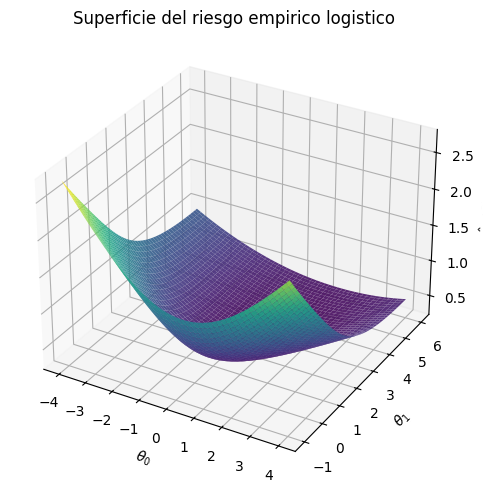

In [3]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, R, cmap='viridis', linewidth=0, antialiased=True, alpha=0.9)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel(r'$\hat R_S(\theta)$')
ax.set_title('Superficie del riesgo empirico logistico')
fig.tight_layout()
fig.savefig('../resultados/ej1_superficie.png', dpi=150)
plt.show()

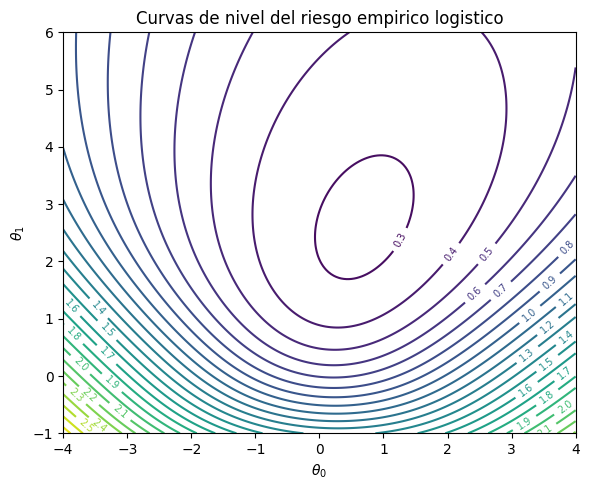

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(T0, T1, R, levels=30, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=7)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title('Curvas de nivel del riesgo empirico logistico')
fig.tight_layout()
fig.savefig('../resultados/ej1_curvas_nivel.png', dpi=150)
plt.show()

### (c) Minimización con `scipy.optimize.minimize` desde $(0,0)$

In [5]:
res1 = ajustar_logistica(x1, y1, theta_init=(0.0, 0.0))
theta_hat_1 = res1.x
print('theta_hat =', theta_hat_1)
print('R_S(theta_hat) =', res1.fun)
print('Convergencia:', res1.success, '-', res1.message)

theta_hat = [0.65   2.5845]
R_S(theta_hat) = 0.2784542389233234
Convergencia: True - Optimization terminated successfully.


### (d) Verificación de que $\hat\theta$ es (al menos localmente) un mínimo,
y marcado del minimizador sobre ambas gráficas

In [6]:
R_hat = riesgo_logistico(theta_hat_1, x1, y1)
R_hat_dtheta0 = riesgo_logistico(theta_hat_1 + np.array([0.1, 0.0]), x1, y1)
R_hat_dtheta1 = riesgo_logistico(theta_hat_1 + np.array([0.0, 0.1]), x1, y1)

print('R_S(theta_hat)              =', R_hat)
print('R_S(theta_hat + (0.1, 0))   =', R_hat_dtheta0)
print('R_S(theta_hat + (0, 0.1))   =', R_hat_dtheta1)
print()
print('R_S(theta_hat) < R_S(theta_hat + (0.1,0)) :', R_hat < R_hat_dtheta0)
print('R_S(theta_hat) < R_S(theta_hat + (0,0.1)) :', R_hat < R_hat_dtheta1)

R_S(theta_hat)              = 0.2784542389233234
R_S(theta_hat + (0.1, 0))   = 0.2788813439799982
R_S(theta_hat + (0, 0.1))   = 0.27866459114450204

R_S(theta_hat) < R_S(theta_hat + (0.1,0)) : True
R_S(theta_hat) < R_S(theta_hat + (0,0.1)) : True


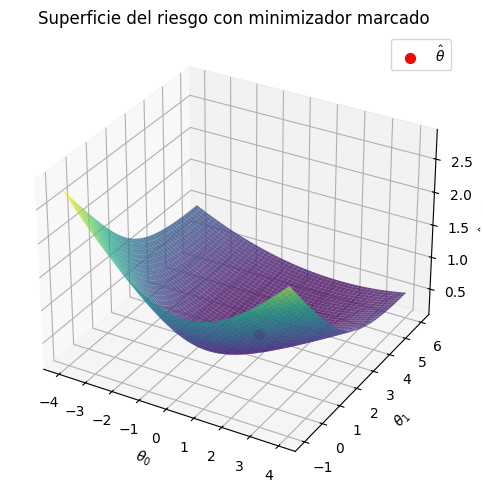

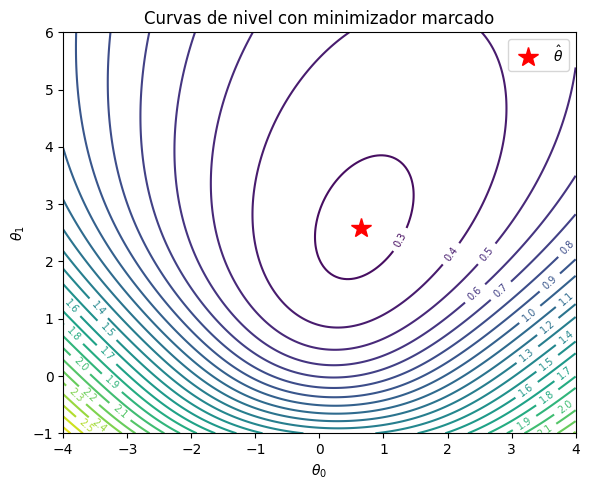

In [7]:
# Volvemos a dibujar ambas figuras, esta vez marcando theta_hat
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, R, cmap='viridis', linewidth=0, antialiased=True, alpha=0.8)
ax.scatter([theta_hat_1[0]], [theta_hat_1[1]], [R_hat], color='red', s=50,
           label=r'$\hat\theta$')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel(r'$\hat R_S(\theta)$')
ax.set_title('Superficie del riesgo con minimizador marcado')
ax.legend()
fig.tight_layout()
fig.savefig('../resultados/ej1_superficie_marcada.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(T0, T1, R, levels=30, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=7)
ax.plot(theta_hat_1[0], theta_hat_1[1], 'r*', markersize=15, label=r'$\hat\theta$')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title('Curvas de nivel con minimizador marcado')
ax.legend()
fig.tight_layout()
fig.savefig('../resultados/ej1_curvas_nivel_marcada.png', dpi=150)
plt.show()

## Ejercicio 2 — Datos separables y no separables

In [8]:
x2 = x1.copy()
yA = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])  # separable
yB = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])  # no separable

res_A = ajustar_logistica(x2, yA, theta_init=(0.0, 0.0))
res_B = ajustar_logistica(x2, yB, theta_init=(0.0, 0.0))

theta_A, theta_B = res_A.x, res_B.x
norma_A = np.linalg.norm(theta_A)
norma_B = np.linalg.norm(theta_B)
riesgo_A = res_A.fun
riesgo_B = res_B.fun

print(f"{'conjunto':10s} {'||theta_hat||':>15s} {'R_S(theta_hat)':>18s}")
print(f"{'A (sep.)':10s} {norma_A:15.4f} {riesgo_A:18.6f}")
print(f"{'B (no sep)':10s} {norma_B:15.4f} {riesgo_B:18.6f}")

conjunto     ||theta_hat||     R_S(theta_hat)
A (sep.)           43.0479           0.000010
B (no sep)          2.6650           0.278454


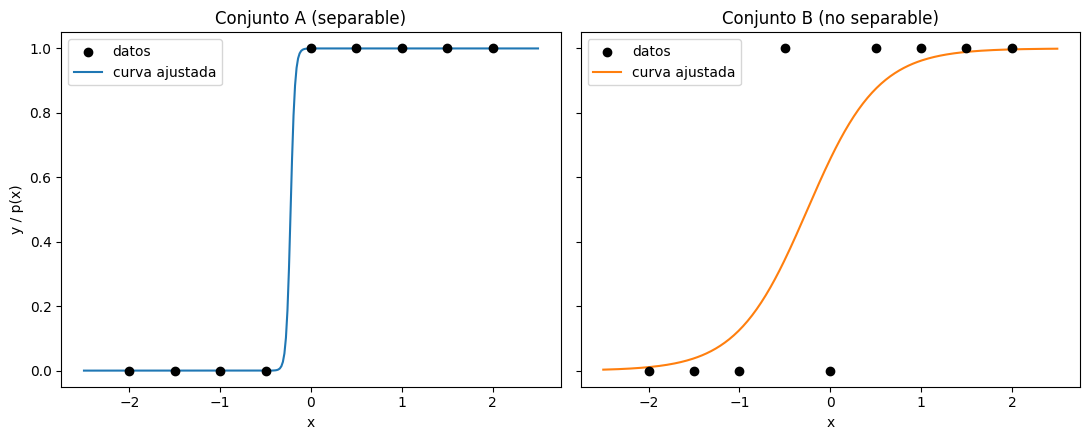

In [9]:
xx = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].scatter(x2, yA, color='black', zorder=3, label='datos')
axes[0].plot(xx, p_theta(xx, theta_A), color='C0', label='curva ajustada')
axes[0].set_title('Conjunto A (separable)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y / p(x)')
axes[0].legend()

axes[1].scatter(x2, yB, color='black', zorder=3, label='datos')
axes[1].plot(xx, p_theta(xx, theta_B), color='C1', label='curva ajustada')
axes[1].set_title('Conjunto B (no separable)')
axes[1].set_xlabel('x')
axes[1].legend()

fig.tight_layout()
fig.savefig('../resultados/ej2_ajustes.png', dpi=150)
plt.show()

### (d) Efecto de `maxiter` sobre el conjunto separable (A)

In [10]:
res_A_10 = ajustar_logistica(x2, yA, theta_init=(0.0, 0.0), maxiter=10)
res_A_100 = ajustar_logistica(x2, yA, theta_init=(0.0, 0.0), maxiter=100)

for etiqueta, res in [('maxiter=10', res_A_10), ('maxiter=100', res_A_100)]:
    theta_ = res.x
    print(f"{etiqueta:12s} theta_hat={theta_}  ||theta_hat||={np.linalg.norm(theta_):.4f}  "
          f"R_S={res.fun:.6f}  convergio={res.success}")

maxiter=10   theta_hat=[ 3.3303 15.6772]  ||theta_hat||=16.0270  R_S=0.005126  convergio=False
maxiter=100  theta_hat=[ 9.4165 42.0053]  ||theta_hat||=43.0479  R_S=0.000010  convergio=True


**Interpretación.** En el conjunto separable no existe un $\hat\theta$ finito que
minimice $\hat R_S$: el óptimo se alcanza en el límite $\|\theta\|\to\infty$
(la curva logística se vuelve un escalón perfecto). Por eso, al aumentar
`maxiter`, el optimizador sigue alejándose del origen: **la norma
$\|\hat\theta\|_2$ aumenta mientras el riesgo $\hat R_S(\hat\theta)$ disminuye
hacia 0**. Esto corresponde a la afirmación **II**.

## Ejercicio 3 — Recuperación de parámetros

In [11]:
theta_star = np.array([-1.0, 2.0])
rng = np.random.default_rng(2026)

ns = [50, 200, 1000]
filas = []
for n in ns:
    x_n, y_n = generar_datos(n, theta_star, rng)
    res_n = ajustar_logistica(x_n, y_n, theta_init=(0.0, 0.0))
    theta_hat_n = res_n.x
    e_n = np.linalg.norm(theta_hat_n - theta_star)
    filas.append((n, theta_hat_n[0], theta_hat_n[1], e_n))

print(f"{'n':>6s} {'theta0_hat':>12s} {'theta1_hat':>12s} {'error e_n':>12s}")
for n, t0, t1, e in filas:
    print(f"{n:6d} {t0:12.4f} {t1:12.4f} {e:12.4f}")

     n   theta0_hat   theta1_hat    error e_n
    50      -1.6138       2.6844       0.9193
   200      -0.8230       2.0382       0.1811
  1000      -1.0660       1.8500       0.1639


In [12]:
errores = {n: e for (n, _, _, e) in filas}
n_min_error = min(errores, key=errores.get)
print('n con menor error:', n_min_error)
print('e_1000 < e_50 :', errores[1000] < errores[50])

n con menor error: 1000
e_1000 < e_50 : True


**Nota.** Como los datos se generan de forma secuencial con el mismo `rng`
(sin reiniciarlo entre tamaños de muestra), lo esperable —y lo que
usualmente se observa— es que el error $e_n=\|\hat\theta_n-\theta^\star\|_2$
disminuya al aumentar $n$, de acuerdo con la consistencia del estimador de
máxima verosimilitud: a mayor tamaño de muestra, menor varianza de
$\hat\theta_n$ y por lo tanto $\hat\theta_n$ se acerca más a $\theta^\star$.

## Ejercicio 4 — Interpretación de los parámetros

### (a) Frontera de decisión

Si $\theta_1\neq 0$:
$$p_\theta(x)=\tfrac12 \iff \sigma(\theta_0+\theta_1 x)=\tfrac12
\iff \theta_0+\theta_1 x = 0 \iff x = -\theta_0/\theta_1,$$
usando que $\sigma(t)=\tfrac12 \iff t=0$ (pues $\sigma$ es estrictamente
creciente y $\sigma(0)=1/2$).

theta0= -2: frontera x*=  2.00,  p_theta(x*)=0.500000
theta0=  0: frontera x*=  0.00,  p_theta(x*)=0.500000
theta0=  2: frontera x*= -2.00,  p_theta(x*)=0.500000


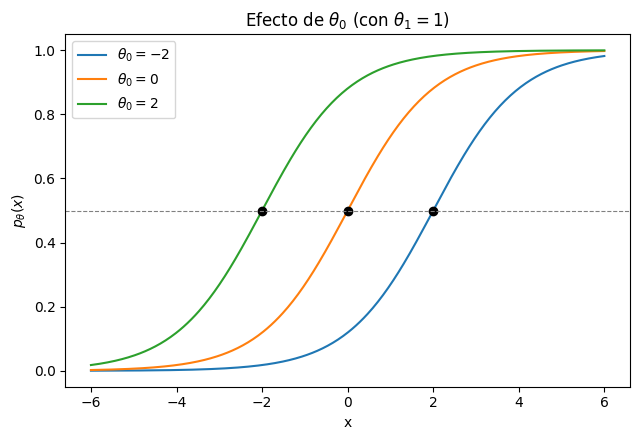

In [13]:
xx = np.linspace(-6, 6, 400)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for theta0 in [-2, 0, 2]:
    theta_ = (theta0, 1.0)
    ax.plot(xx, p_theta(xx, theta_), label=fr'$\theta_0={theta0}$')
    x_frontera = -theta0 / 1.0
    p_frontera = p_theta(np.array([x_frontera]), theta_)[0]
    ax.plot(x_frontera, p_frontera, 'ko')
    print(f'theta0={theta0:>3}: frontera x*={x_frontera:6.2f},  '
          f'p_theta(x*)={p_frontera:.6f}')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('x'); ax.set_ylabel(r'$p_\theta(x)$')
ax.set_title(r'Efecto de $\theta_0$ (con $\theta_1=1$)')
ax.legend()
fig.tight_layout()
fig.savefig('../resultados/ej4_theta0.png', dpi=150)
plt.show()

theta1=1: p(1)-p(-1) = 0.462117
theta1=2: p(1)-p(-1) = 0.761594
theta1=5: p(1)-p(-1) = 0.986614
Modelo con transicion mas abrupta: theta1 = 5


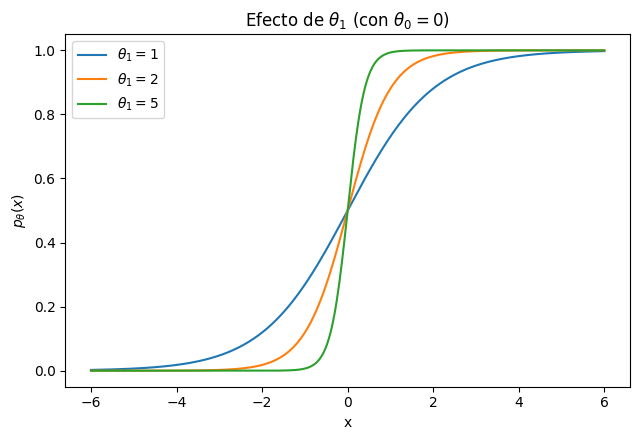

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
transiciones = {}
for theta1 in [1, 2, 5]:
    theta_ = (0.0, theta1)
    ax.plot(xx, p_theta(xx, theta_), label=fr'$\theta_1={theta1}$')
    delta = p_theta(np.array([1.0]), theta_)[0] - p_theta(np.array([-1.0]), theta_)[0]
    transiciones[theta1] = delta
    print(f'theta1={theta1}: p(1)-p(-1) = {delta:.6f}')

theta1_mas_abrupta = max(transiciones, key=transiciones.get)
print('Modelo con transicion mas abrupta: theta1 =', theta1_mas_abrupta)

ax.set_xlabel('x'); ax.set_ylabel(r'$p_\theta(x)$')
ax.set_title(r'Efecto de $\theta_1$ (con $\theta_0=0$)')
ax.legend()
fig.tight_layout()
fig.savefig('../resultados/ej4_theta1.png', dpi=150)
plt.show()

**Interpretación.** $\theta_0$ desplaza horizontalmente la frontera de
decisión ($x^\star=-\theta_0/\theta_1$) sin cambiar su pendiente, mientras que
$\theta_1$ controla qué tan abrupta es la transición de 0 a 1: entre mayor
$|\theta_1|$, mayor es $p_\theta(1)-p_\theta(-1)$ y más se parece la curva a un
escalón. En este caso, $\theta_1=5$ produce la transición más abrupta.

## Ejercicio 5 — Verosimilitud y estabilidad numérica

In [15]:
rng5 = np.random.default_rng(2026)
x5, y5 = generar_datos(5000, theta_star, rng5)

L_star = verosimilitud(theta_star, x5, y5)
logL_star = log_verosimilitud(theta_star, x5, y5)

print('L(theta*)     =', L_star)
print('log L(theta*) =', logL_star)

L(theta*)     = 0.0
log L(theta*) = -1954.920071716625


### (b) ¿Sigue siendo finita la log-verosimilitud aunque $L(\theta^\star)$ se
redondee a 0.0?

In [16]:
print('L(theta*) == 0.0 ?', L_star == 0.0)
print('log L(theta*) es finito ?', np.isfinite(logL_star))

L(theta*) == 0.0 ? True
log L(theta*) es finito ? True


Con $n=5000$ observaciones, el producto de 5000 probabilidades (cada una
menor que 1) subdesborda a 0.0 en aritmética de punto flotante (underflow),
aunque la verosimilitud "verdadera" sea un número positivo extremadamente
pequeño, no exactamente cero. La log-verosimilitud, en cambio, es una
**suma** de 5000 términos finitos y por lo tanto se mantiene perfectamente
representable como un número finito: por esto siempre se trabaja en escala
logarítmica al maximizar verosimilitud.

### (c) Relación entre la log-verosimilitud y el riesgo empírico

Por construcción, $\log L(\theta) = -n\,\hat R_S(\theta)$. Verifiquemos
numéricamente que $\Delta = |-\log L(\theta^\star) - n\,\hat R_S(\theta^\star)|<10^{-8}$.

In [17]:
n5 = len(x5)
R_star = riesgo_logistico(theta_star, x5, y5)
delta = abs(-logL_star - n5 * R_star)

print('R_S(theta*)        =', R_star)
print('n * R_S(theta*)     =', n5 * R_star)
print('-log L(theta*)      =', -logL_star)
print('Delta               =', delta)
print('Delta < 1e-8 ?       ', delta < 1e-8)

R_S(theta*)        = 0.39098401434332497
n * R_S(theta*)     = 1954.9200717166248
-log L(theta*)      = 1954.920071716625
Delta               = 2.2737367544323206e-13
Delta < 1e-8 ?        True


La identidad se verifica (salvo error de redondeo de punto flotante, del
orden de $10^{-12}$–$10^{-13}$), confirmando que minimizar el riesgo
empírico logístico $\hat R_S(\theta)$ es equivalente a maximizar la
log-verosimilitud del modelo Bernoulli con $p_\theta(x)$.